In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
from scipy import stats

In [110]:
con = sqlite3.connect(r'D:\inventory.db')

df = pd.read_sql("""SELECT * FROM VendorSalesSummery""", con)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfutMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [111]:
# Exploratory Data Analysis :->
# Previously, we examined the various tables in the database to identify key variables, 
# understand their relationships, and determine which ones should be included in the final analysis.
# In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column.
# This will help us understand data patterns, identify anomalies, and 
# ensure data quality before proceeding with further analysis.

In [112]:
# Summary Statistics :->
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10514.0,3129.583317,11037.801407,1.000000,36.000000,280.000000,1985.000000,3.349390e+05
TotalSalesDollar,10514.0,42954.173834,168977.755843,1.980000,809.820000,5599.700000,29524.250000,5.101920e+06
TotalSalesPrice,10514.0,19111.958773,45264.605387,0.990000,334.890000,3020.085000,16442.477500,6.728193e+05


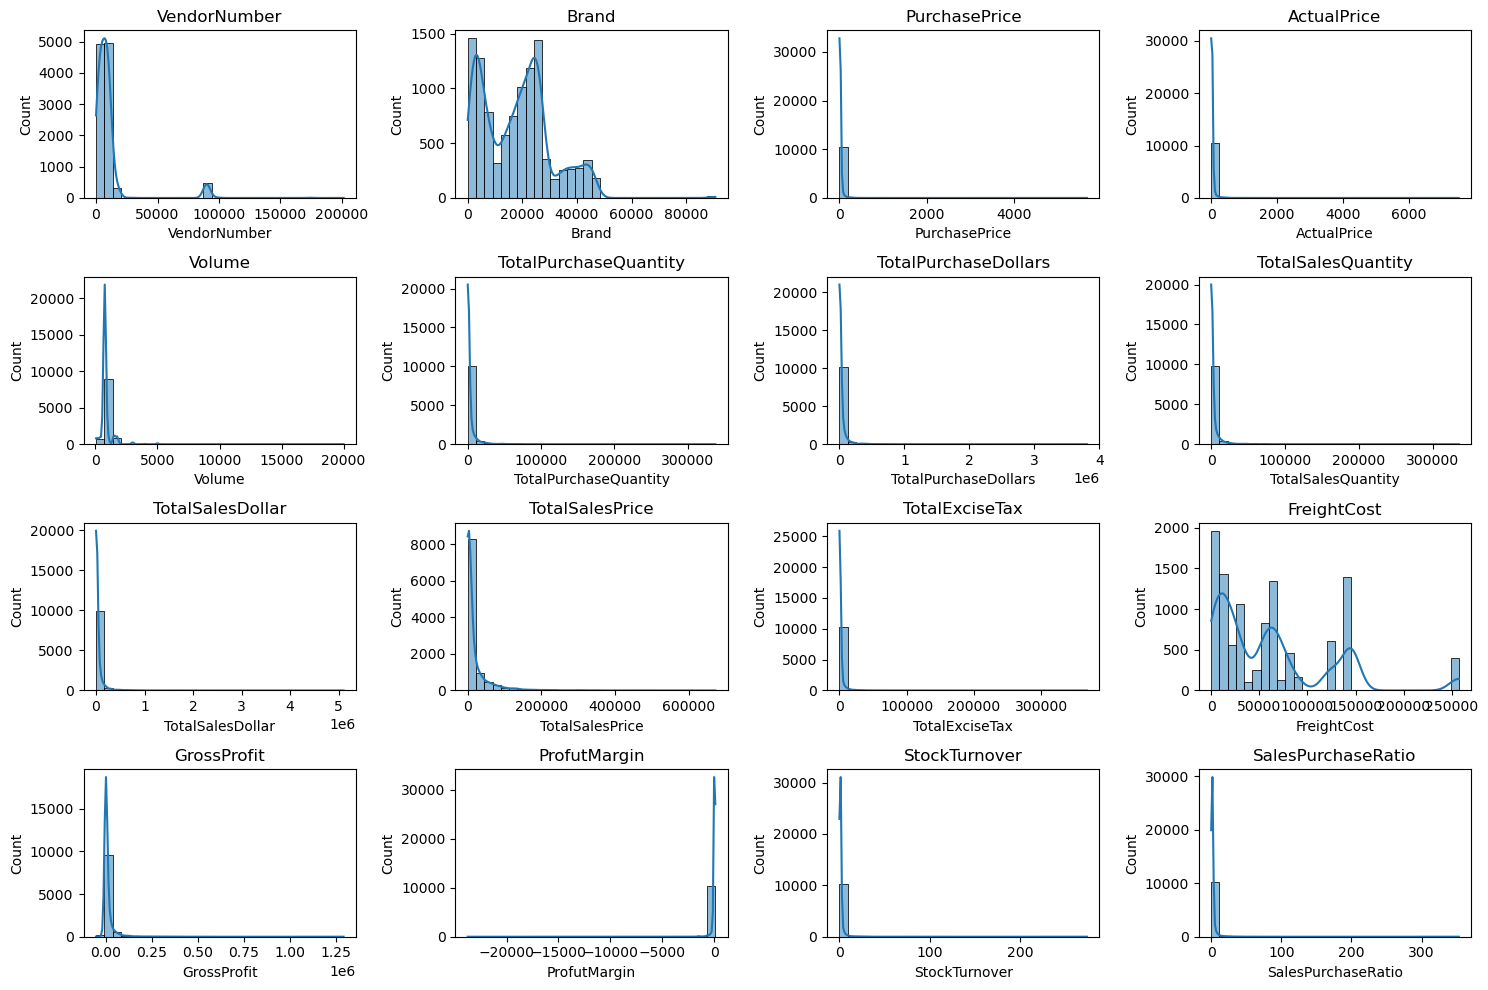

In [113]:
numerical_col = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_col) :
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

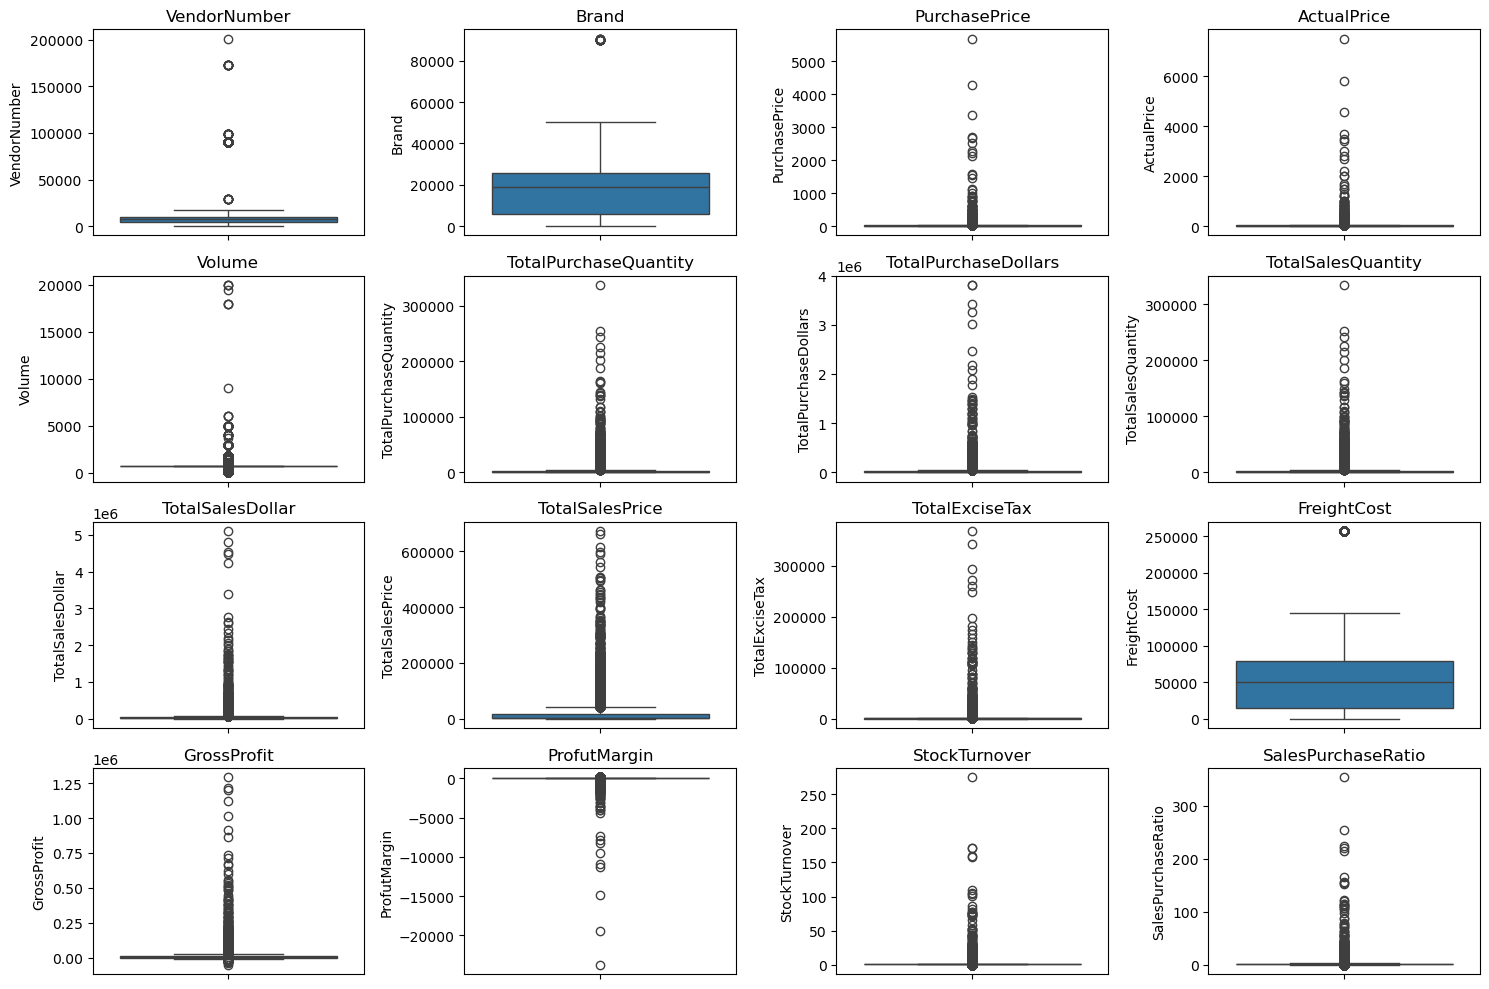

In [114]:
# Detecting Outliers :->
plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_col) :
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [115]:
# Summary Statistics Insights:->
# Negative & Zero Values:
# Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions 
#               may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
# Profit Margin: Has a minimum of -ve infinite, which suggests cases where revenue is zero or even lower than costs.
# Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. 
#                                       These could be slow-moving or obsolete stock.
# Outliers Indicated by High Standard Deviations:
# Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher 
#                           than the mean (24.39 & 35.64), indicating potential premium products.
# Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
# Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast 
#                 while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity 
#                 for that product is higher than purchased quantity due to either sales are being \
#                 fulfilled from older stock.

In [116]:
# Filtering the dataset by removing above Inconsistencies :
df = pd.read_sql("""
SELECT * FROM VendorSalesSummery
WHERE GrossProfit > 0 AND ProfutMargin > 0 AND TotalSalesQuantity > 0""", con)

In [117]:
df.to_csv('New_Vendor_Performance.csv', index=False)

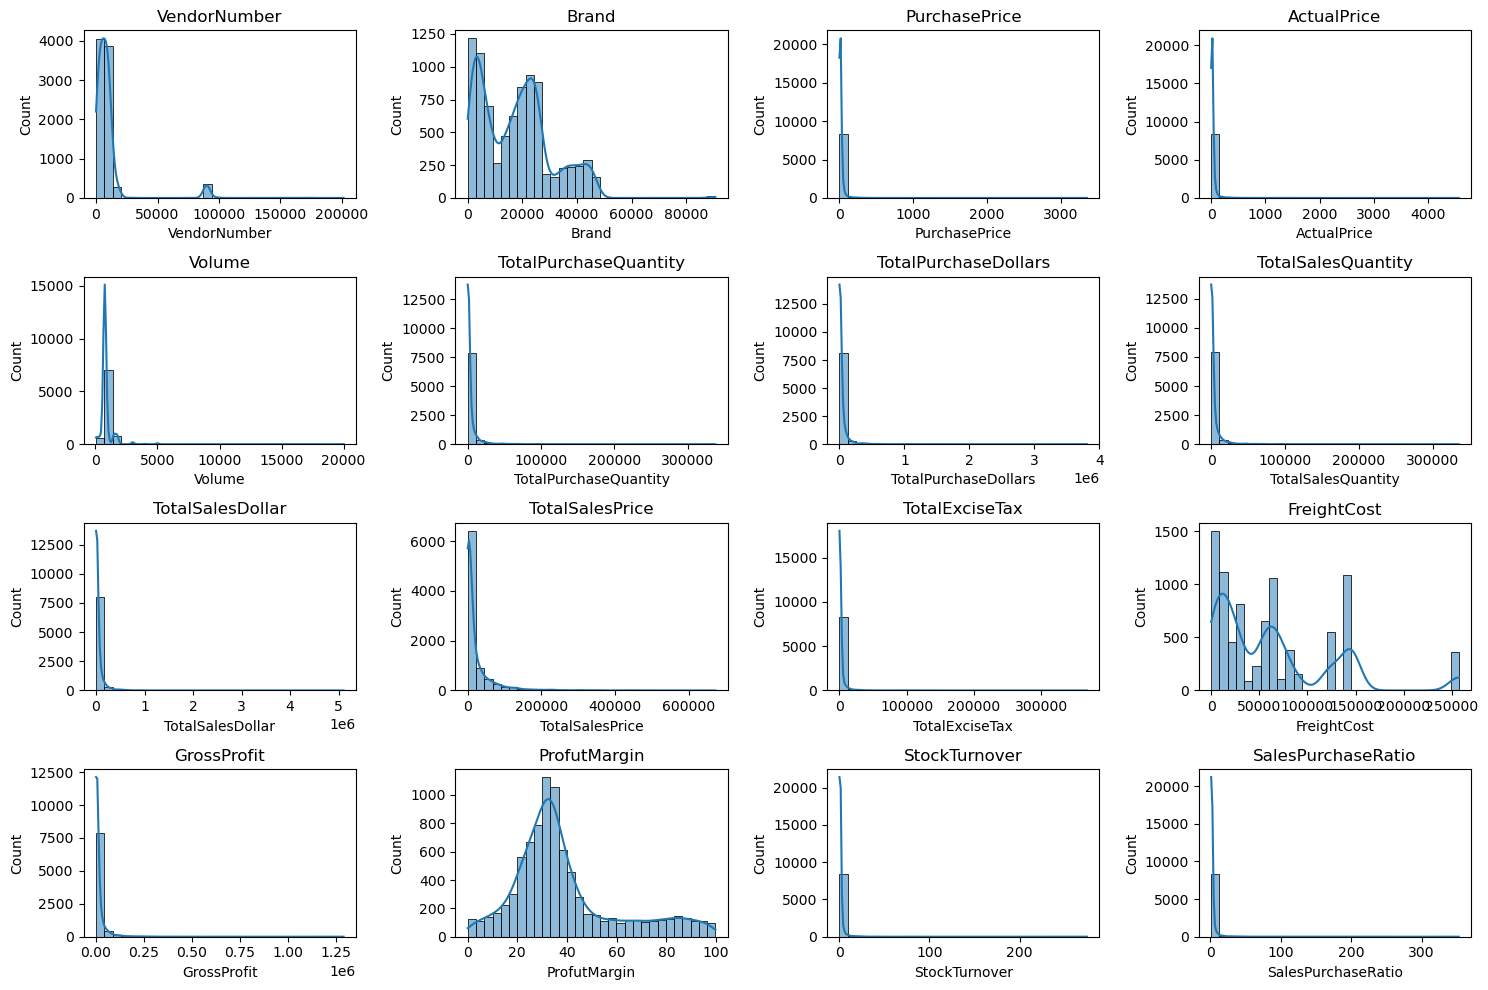

In [118]:
numerical_col = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_col) :
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

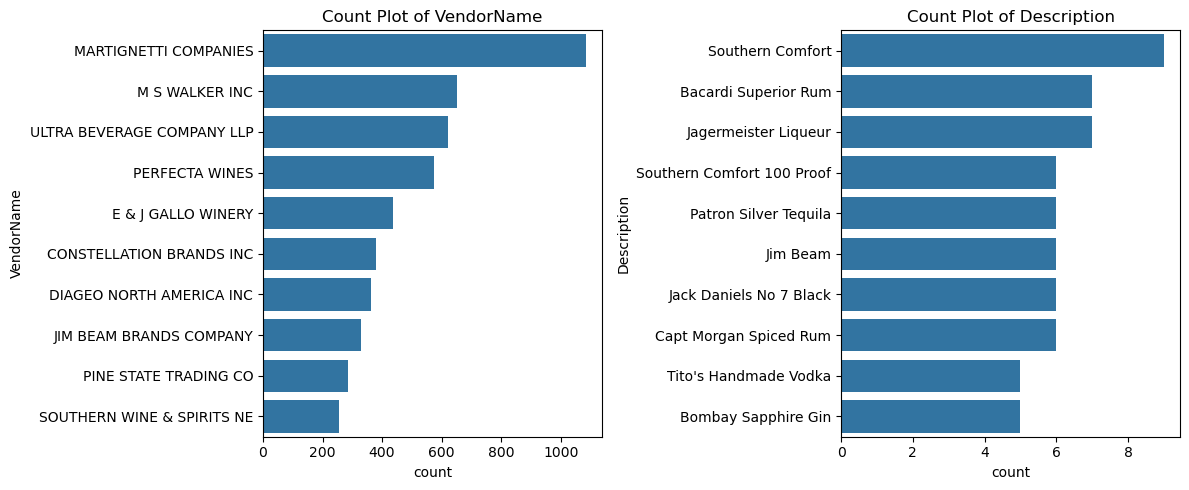

In [119]:
# Count Plot of categorical column :->
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize = (12, 5))
for i, col in enumerate(categorical_cols) :
    plt.subplot(1, 2, i + 1)
    sns.countplot(df[col], order = df[col].value_counts().index[ : 10])
    plt.title(f'Count Plot of {col}')
plt.tight_layout()
plt.show()

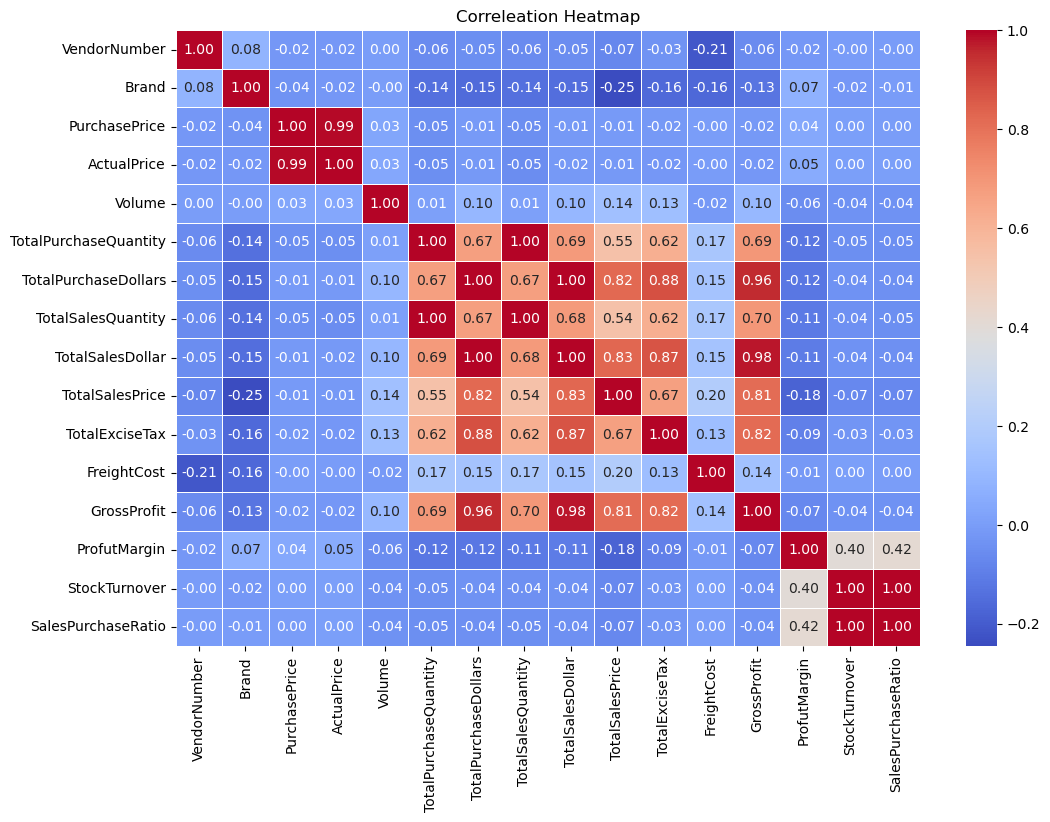

In [120]:
# Corrleation Hearmap :->
plt.figure(figsize = (12, 8))
correlation_matix = df[numerical_col].corr()
sns.heatmap(correlation_matix, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correleation Heatmap')
plt.show()

# Correlation Insights
# PurchasePrice has weak correlations with TotalSales Dollars (-0.012) and Gross Profit (-0.016), 
#           suggesting that price variations do not significantly impact sales revenue or profit.
# Strong correlation between total purchase quantity and total sales quantity (0.999), 
#           confirming efficient inventory turnover.
# Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases,
#           margins decrease, possibly due to competitive pricing pressures.
# Stock Turnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055),
#           indicating that faster turnover does not necessarily result in higher profitability

In [121]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 1 :->
# Identify Brands that needs Promotionalor or Pricing Adjestements which exhibit lower sales 
# performance but highter Profit Margine.
brand_performance = df.groupby('Description').agg({'TotalSalesDollar' : 'sum', 'ProfutMargin' : 'mean'}).reset_index()

In [122]:
low_sales_threshold = brand_performance['TotalSalesDollar'].quantile(0.15)
high_margin_threshold = brand_performance['ProfutMargin'].quantile(0.85)
print(f'Low Sales Threshold : {low_sales_threshold}')
print(f'High Margin Threshold : {high_margin_threshold}')

Low Sales Threshold : 560.299
High Margin Threshold : 64.97017552750113


In [123]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollar'] <= low_sales_threshold) & 
    (brand_performance['ProfutMargin'] >= high_margin_threshold)]

target_brands

,Description,TotalSalesDollar,ProfutMargin
6,12 Days of Pearls Gift Set,309.69,97.678323
45,4 Orange Vodka,483.78,85.902683
57,A Bichot Clos Marechaudes,539.94,67.740860
59,A Bichot Merc Champs M,515.88,94.552997
96,Absolut Orient Apple Vodka,119.94,87.652159
...,...,...,...
7588,Woodford Rsv Master Coll Pnt,489.95,73.760588
7663,Zardetto Pros di Coneg Brut,345.86,88.758457
7677,Zerran Tinto Montsant,139.91,77.592738
7686,Zhenka Vodka 80 Proof,240.39,87.303964


In [124]:
# Therefore above are the 199 brand out of total of around 7000 brands who have very less sales but their 
# profit margin is very high, therefore they require promotional assistance and pricing 
# adjustment to increase revenue.

In [125]:
brand_performance = brand_performance[brand_performance['TotalSalesDollar'] < 1000]

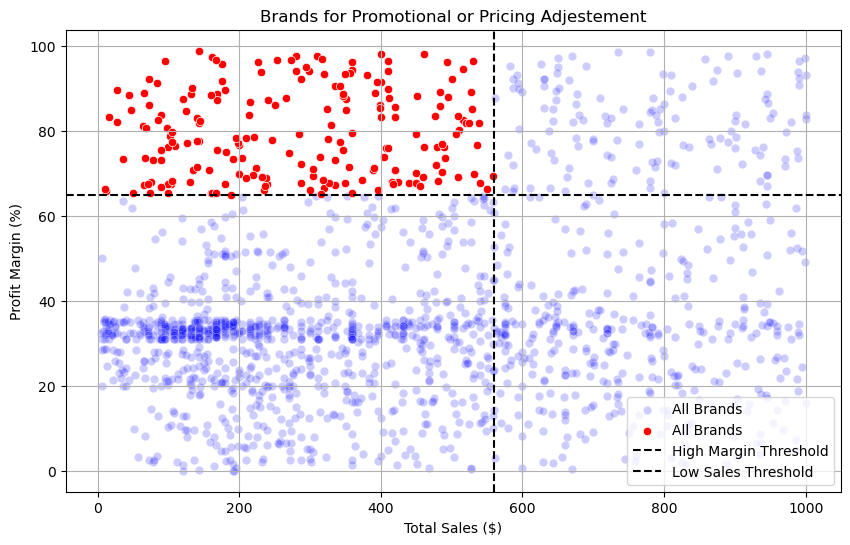

In [126]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollar', y = 'ProfutMargin', color = 'blue', label = 'All Brands', alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollar', y = 'ProfutMargin', color = 'red', label = 'All Brands')

plt.axhline(high_margin_threshold, linestyle = '--', color = 'black', label = 'High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color = 'black', label = 'Low Sales Threshold')

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title('Brands for Promotional or Pricing Adjestement')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
def format_dollars(values) :
    if values >= 1_000_000 :
        return f"{values / 1_000_000:.2f}M"
    elif values >= 1_000 : 
        return f"{values / 1_000:.2f}k"
    else :
        return str(values)

In [128]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 2 :->
# Which vendor and brand demonstrates the highest sales performance.
top_vendors = df.groupby(['VendorName'])['TotalSalesDollar'].sum().nlargest(10)
top_brand = df.groupby(['Description'])['TotalSalesDollar'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollar, dtype: float64

In [129]:
top_brand.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollar, dtype: object

C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\4205114961.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(y = top_vendors.index, x = top_vendors.values, palette = "Blues_r")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\4205114961.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(y = top_brand.index.astype(str), x = top_brand.values, palette = "Reds_r")


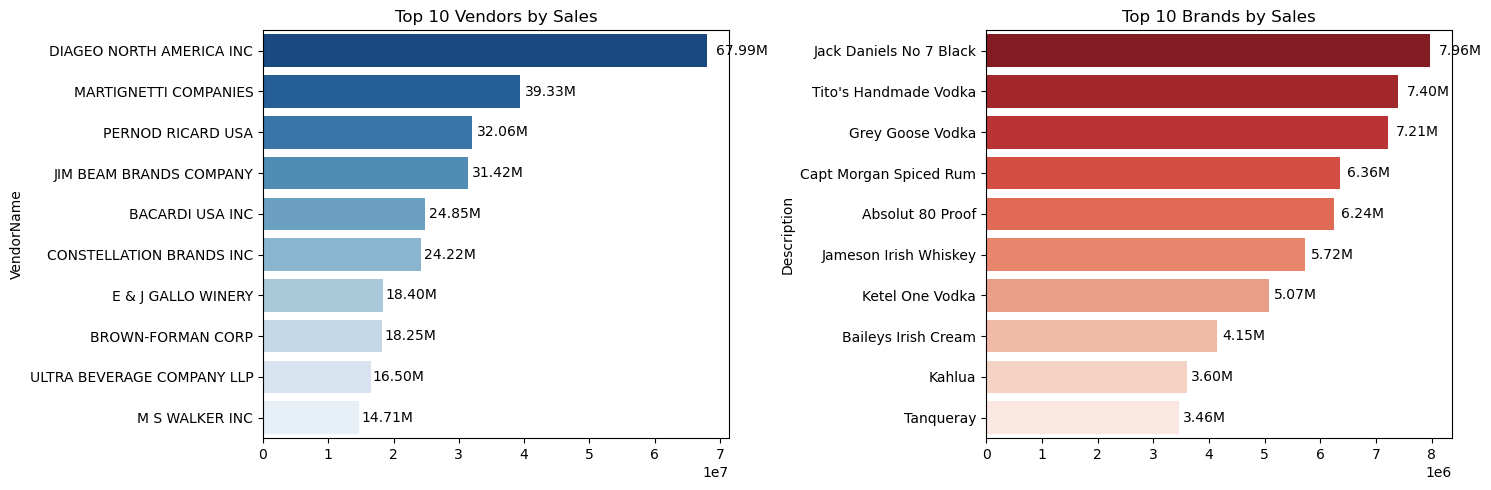

In [130]:
plt.figure(figsize = (15, 5))

# Plot for Top Venders :
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y = top_vendors.index, x = top_vendors.values, palette = "Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches : 
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')
    
#Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y = top_brand.index.astype(str), x = top_brand.values, palette = "Reds_r")
plt.title("Top 10 Brands by Sales")
for bar in ax2.patches : 
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')
    
plt.tight_layout()
plt.show()

In [131]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 3 :->
# Which vendor contributes the most to total purchase dollars?

In [132]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollar' : 'sum'
}).reset_index()

In [133]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum() * 100

In [134]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False), 2)

In [135]:
top_venders = vendor_performance.head(10)
top_venders['TotalPurchaseDollars'] = top_venders['TotalPurchaseDollars'].apply(format_dollars)
top_venders['GrossProfit'] = top_venders['GrossProfit'].apply(format_dollars)
top_venders['TotalSalesDollar'] = top_venders['TotalSalesDollar'].apply(format_dollars)
top_venders

C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\2477124863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_venders['TotalPurchaseDollars'] = top_venders['TotalPurchaseDollars'].apply(format_dollars)
C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\2477124863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_venders['GrossProfit'] = top_venders['GrossProfit'].apply(format_dollars)
C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\2477124863.py:4: SettingWithCopyWarning: 
A value is trying to be

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollar,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [136]:
top_venders['CumulativeContribution%'] = top_venders['PurchaseContribution%'].cumsum()
top_venders

C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\465853524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_venders['CumulativeContribution%'] = top_venders['PurchaseContribution%'].cumsum()


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollar,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\1045426722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_venders['VendorName'], y = top_venders['PurchaseContribution%'], palette="mako", ax = ax1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\1045426722.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels (top_venders['VendorName'], rotation = 90)


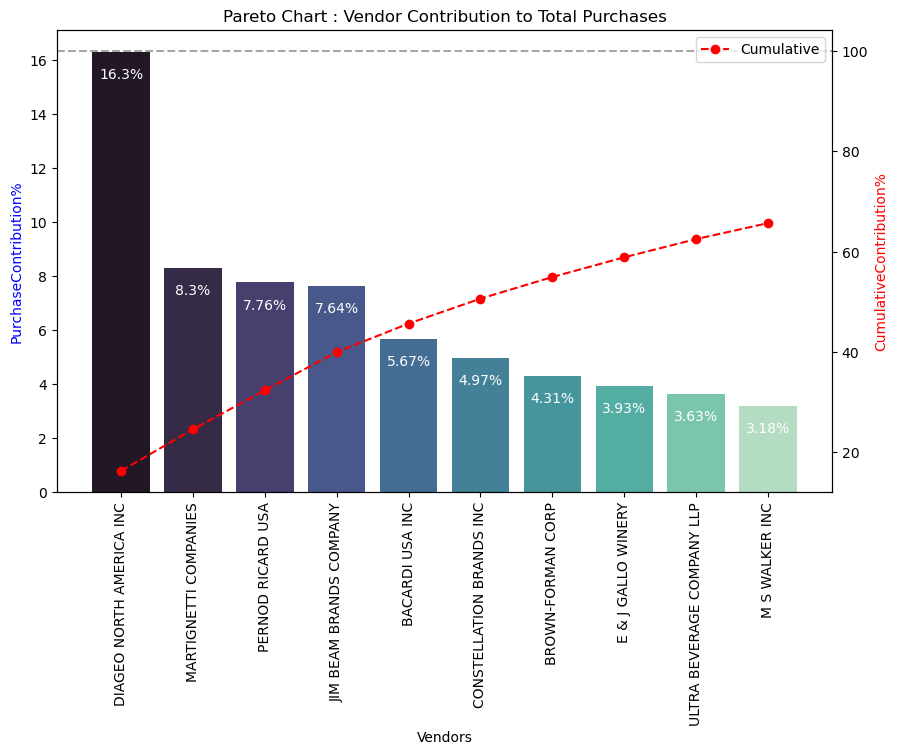

In [137]:
fig, ax1 =  plt.subplots(figsize = (10, 6))

#Bar plot for Purchase Contribution
sns.barplot(x = top_venders['VendorName'], y = top_venders['PurchaseContribution%'], palette="mako", ax = ax1)
for i, value in enumerate(top_venders['PurchaseContribution%']) :
    ax1.text(i, value - 1, str(value)+'%', ha = 'center', fontsize = 10, color = 'white')

#Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_venders['VendorName'], top_venders['CumulativeContribution%'], color = 'red', marker = 'o', linestyle = 'dashed', label = 'Cumulative')

ax1.set_xticklabels (top_venders['VendorName'], rotation = 90)
ax1.set_ylabel('PurchaseContribution%', color = 'blue')
ax2.set_ylabel('CumulativeContribution%', color = 'red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchases')

ax2.axhline(y = 100, color = 'gray', linestyle = 'dashed', alpha = 0.7)
ax2.legend(loc = 'upper right')
plt.show()

In [138]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 4 :->
# How much of the total procurement is dependent on the top vendors.

In [139]:
print(f'Purchase Contribution of top 10 vendors is {round(top_venders['PurchaseContribution%'].sum(), 2)}%.')

Purchase Contribution of top 10 vendors is 65.69%.


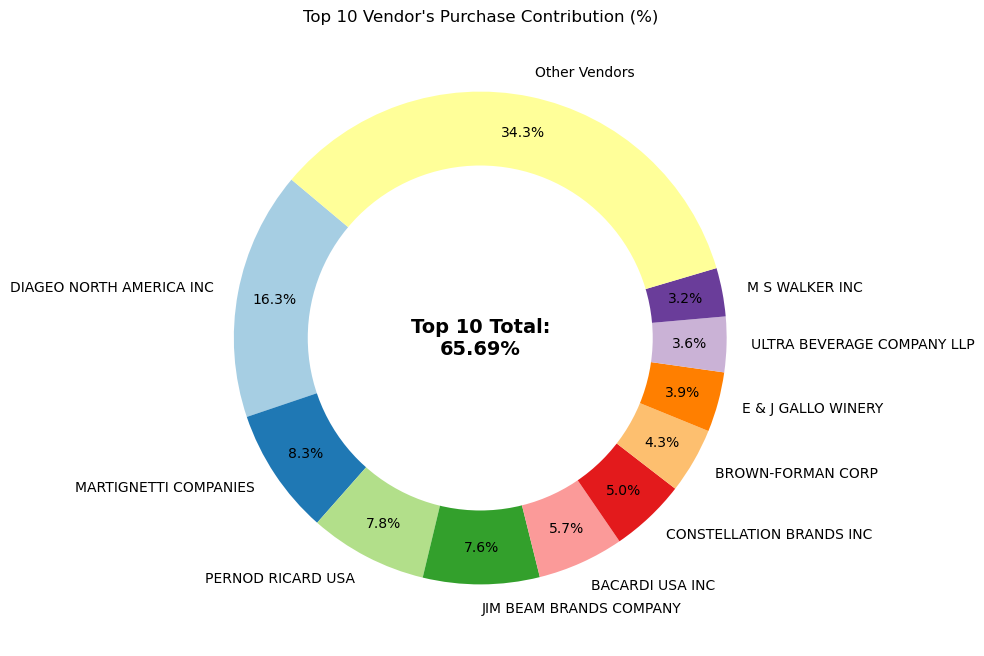

In [140]:
vendors = list(top_venders['VendorName'].values)
purchase_contributions = list(top_venders['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#Donut Chart
fig, ax = plt.subplots (figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels = vendors, autopct = '%1.1f%%',
                                  startangle = 140, pctdistance = 0.85, colors = plt.cm.Paired.colors)

#Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')
plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [141]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 4 :->
# Does purchasing in bulk reduces the unit price, and what is the optimal purchase volume for cost savings?

In [142]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [143]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q = 3, labels = ['Small', 'Medium', 'Large'])

In [144]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\1505448859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


C:\Users\DELL\AppData\Local\Temp\ipykernel_19976\4175287664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'OrderSize', y = 'UnitPurchasePrice', palette = 'Set2')


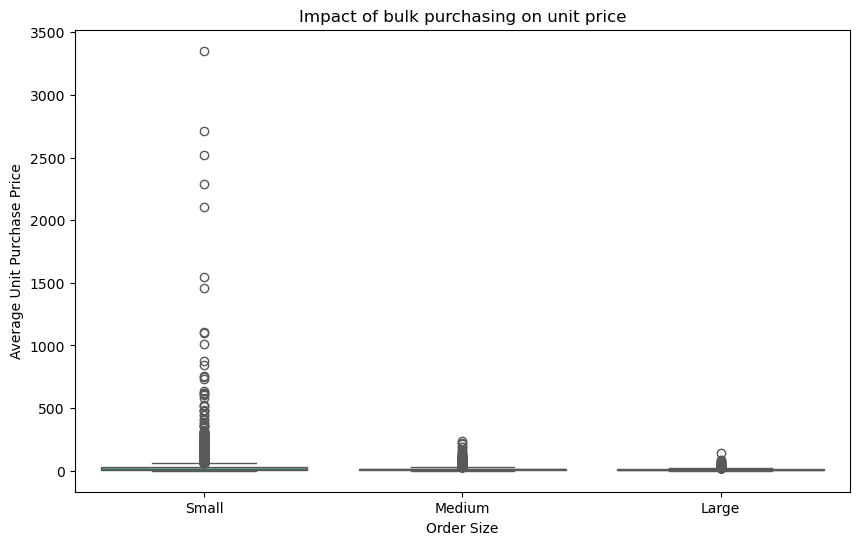

In [145]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = 'OrderSize', y = 'UnitPurchasePrice', palette = 'Set2')
plt.title('Impact of bulk purchasing on unit price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

In [146]:
# 1.) Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), 
#     meaning higher margins if they can manage inventory efficiently.
# 2.) The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
# 3.) This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes,
#     leading to higher overall sales despite lower per-unit revenue.

In [147]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 5 :->
# Which vendors have low inventory turnover, indicating excess stock and slow-moving products.

In [148]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover').head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [149]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 6 :->
# How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it.

In [150]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df ["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital :', format_dollars(df["UnsoldInventoryValue"].sum()))


Total Unsold Capital : 2.71M


In [151]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = "UnsoldInventoryValue", ascending = False) 
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor ['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


In [152]:
# -----------------------------------------------------------------------------------------------------------------
# Business Problem 7 :->
# What is the 95% conidence intervals for profit margins of top-performing and low-performing vendors.

In [153]:
top_threshold = df['TotalSalesDollar'].quantile(0.75)
low_threshold = df['TotalSalesDollar'].quantile(0.75)

In [154]:
top_vendors = df[df["TotalSalesDollar"] >= top_threshold]["ProfutMargin"].dropna()
low_vendors = df[df["TotalSalesDollar"] <= low_threshold]["ProfutMargin"].dropna()

In [155]:
def ConfidenceInterval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df = len(data) - 1)
    
    margin_of_error = t_critical * std_err
    
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.67, 41.81), Mean: 41.24


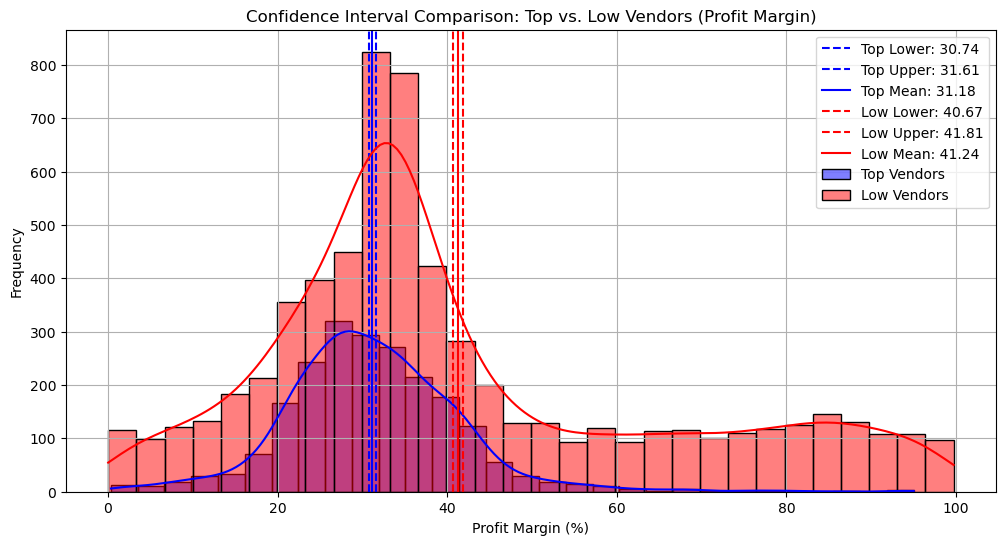

In [156]:
top_mean, top_lower, top_upper = ConfidenceInterval(top_vendors)
low_mean, low_lower, low_upper = ConfidenceInterval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")


plt.figure(figsize=(12,6))
# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")
# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")
# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [157]:
# 1.) The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher 
#     than that of top-performing vendors (30.74% to 31.61%).
# 2.) This suggests that vendors with lower sales tend to maintain higher profit margins, 
#     potentially due to premium pricing or lower operational costs.
# 3.) For High-Performing Vendors: If they aim to improve profitability, they could explore 
#     selective price adjustments, cost optimization, or bundling strategies.
# 4.) For Low-Performing Vendors: Despite higher margins, their low sales volume might 
#     indicate a need for better marketing, competitive pricing, or improved distribution strategies.

In [158]:
# Hypothesis Testing :->
# Is there a significant difference in profit margins between top-performing and low-performing vendors?
# H(0) (Null Hypothesis): There is no significant difference in the mean profit margins of 
#                         top-performing and low-performing vendors.
# H(1) (Alternative Hypothesis): The mean profit margins of top-performing and low-performing
#                                vendors are significantly different.


top_threshold = df["TotalSalesDollar"].quantile(0.75)
low_threshold = df["TotalSalesDollar"].quantile(0.25)

top_vendors = df[df["TotalSalesDollar"] >= top_threshold]["ProfutMargin"].dropna()
low_vendors = df[df["TotalSalesDollar"] <= low_threshold]["ProfutMargin"].dropna()
#Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

print(f"T-Statistic: {t_stat:.2f}, P-Value: {p_value:.2f}")
if p_value < 0.05:
    print("Reject H(0): There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H(1): No significant difference in profit margins.")

T-Statistic: -17.67, P-Value: 0.00
Reject H(0): There is a significant difference in profit margins between top and low-performing vendors.
